In [40]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))


/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_12951/3522731578.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [41]:
import sys
sys.path.append('../../' \
'')
import glob
import os
import nrrd
from dipy.io.image import load_nifti
from dipy.io.gradients import read_bvals_bvecs
import matplotlib.pyplot as plt
import time
# from mystic_mrpy.Data_Sorting.Diffusion            import *
from cardpy.Data_Sorting import *
from skimage.measure import label
import numpy as np
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny
from skimage.morphology import flood_fill
from cardpy.Data_Processing.DWI import DWI_recon
# from mystic_mrpy.Diffusion.DTI import DTI_recon
# from mystic_mrpy.Colormaps.Diffusion import cDTI_Colormaps_Generator
from cardpy.Colormaps import *
# from mystic_mrpy.Data_Saving.Diffusion   import *
from cardpy.Data_Saving import *

# from mystic_mrpy.Diffusion.Registration            import *
# from mystic_mrpy.Diffusion.Denoising               import *
# from mystic_mrpy.Diffusion.Interpolation           import *
from cardpy.Data_Processing.Registration import *
from cardpy.Data_Processing.Denoising import *
from cardpy.Data_Processing.Interpolation import *
from cardpy.Data_Processing.Diffusivity import *

from joblib import Parallel, delayed
import multiprocessing

from scipy.io import savemat
import pandas as pd

import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../' \
'')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *

# import nibabel as nib

In [42]:
cDTI_cmaps = cDTI_Colormaps_Generator()

In [43]:
main_image_path        = '/Volumes/T7/Stim-CODE/NifTi'
main_outpath = '/Volumes/T7/Stim-CODE/Bootstrapping/'

In [44]:
Subject_folders    = ['Phantom_Head'] #['V001','V002','V003','V004','V005','V006','V007','V008','V009','V010',]
DTI_type_list       = ['ep2d_diff_m0_ext_b1000_sos_mmt0',
                       'gropt_mmt0_Ncalib2',
                       'gropt_mmt1_Ncalib2',
                       'trap_mmt0_Ncalib2',
                       'trap_mmt1_Ncalib2']
sub_DTI_Folder = '02_Registered_Global'
iterations     = 400
ADC_Filter_Mode = 'OFF'

In [45]:
# masks     = []
headers   = []
matricies = []
bvalues   = []
bvectors  = []
labels    = []

In [46]:
def Header_Reader(header_path):
    with open(header_path) as f:
        lines = f.readlines()
    HeadersDict = dict()
    for idx in range(len(lines)):
        key_word              = lines[idx].split(':')[0]
        key_value             = lines[idx].split(':')[1]
        key_value             = key_value.strip()
        key_value_clear       = key_value.split(' ')[0]
        HeadersDict[key_word] = key_value_clear
    return HeadersDict

In [47]:
def diffusion_bootstrap(original_matrix, original_bvals, original_bvecs, desired_averages, iterations=1000):
    """
    ########## Definition Inputs ##################################################################################################################
    original_matrix         : Sorted diffusion data (5D - [rows, columns, slices, directions, averages]).
    ########## Definition Outputs #################################################################################################################
    bootstrap_matrix        : Sorted bootstrapped diffusion data (5D - [rows, columns, slices, directions, bootstrap iterations]).
    ########## Definition Information #############################################################################################################
    ### Written by Tyler E. Cork, tyler.e.cork@gmail.com
    ### Cardiac Magnetic Resonance (CMR) Group, Leland Stanford Jr University, 2022
    """
    ########## Import modules #####################################################################################################################
    import numpy as np                                                                                                 # Import numpy module
    import random                                                                                                      # Import random module
    ########## Extract Matrix Size ################################################################################################################
    rows       = original_matrix.shape[0]                                                                              # Extract number of rows
    columns    = original_matrix.shape[1]                                                                              # Extract number of columns
    slices     = original_matrix.shape[2]                                                                              # Extract number of slices
    directions = original_matrix.shape[3]                                                                              # Extract number of directions
    averages   = original_matrix.shape[4]                                                                              # Extract number of averages
    ########## Store Direction and Average Information ############################################################################################
    dirs_vs_avgs_matrix = np.zeros((averages, directions),dtype = original_matrix.dtype)                                                             # Initialize direcions vs averages matrix
    for avgs in range(averages):                                                                                       # Iterate through averages
        for dirs in range(directions):                                                                                     # Iterate through directions
            avg_term                        = avgs + 1                                                                          # Define average term
            dir_term                        = (dirs + 1) / 1000                                                                 # Define direction term
            end_term                        = 4 / 1000                                                                          # Define end term
            dirs_vs_avgs_matrix[avgs, dirs] = np.round((avg_term + dir_term + end_term), 3)                                     # Store direction and average information in direcions vs averages matrix
    ########## Randomly Bootstrap Unique Datasets for each Iteration  #############################################################################
    total_iterations = desired_averages * iterations
    permentation     = averages ** directions * desired_averages                                                                          # Calculate permutation of data
    if total_iterations > permentation:                                                                                       # If iterations is greater than permutation ...
        total_iterations = permentation                                                                                            # Redefine number of iterations
        print('Desired iterations is not possible with current dataset.')                                                    # Print warning
        print('Iterations has been set to the permutation of directions and averages with replacment.')                      # Print warning
    print('Number of iterations to be performed: %i' %int(total_iterations))                                                   # Print warning
    iterations_matrix = np.zeros((total_iterations + 1, directions))                                                           # Initalize iteration matrix with one extra iteration
    for iters in range(total_iterations):                                                                                      # Iterate through iterations
        while iterations_matrix[iters, :].tolist() in iterations_matrix.tolist():                                            # While current iteration is in iteration maxtrix ...
            current_iteration = np.zeros((1, directions))                                                                        # Ititalize current iteration
            for dirs in range(directions):                                                                                       # Iterate through directions
                random_avgerage            = random.randint(0, averages - 1)                                                         # Select random average
                current_iteration[0, dirs] = dirs_vs_avgs_matrix[random_avgerage, dirs]                                              # Set current iteration with random average
            current_iteration_list = current_iteration.tolist()                                                                  # Convert current iteration to list
            iterations_list        = iterations_matrix.tolist()                                                                  # Convert iterations matrix to list
            check_var              = any(item in current_iteration_list for item in iterations_list)                             # Check variable for current iteration list in iterations list
            if not check_var:                                                                                                # If check variable is false ... 
                iterations_matrix[iters, :] = current_iteration[0, :]                                                            # Store current iteration in iteration matrix
                break                                                                                                            # Break while loop to continue to next iteration
    iterations_matrix = iterations_matrix[:-1, :]                                                                          # Remove extra iteration from iteration matrix
    ########## Extract Bootstrap Averages #########################################################################################################
    # directions_matrix = np.zeros((directions, iterations))                                                                # Initialize direction matrix (Removed: not necessary)
    avgerage_matrix   = np.zeros((directions, total_iterations))                                                                 # Initialize average matrix
    for iters in range(total_iterations):                                                                                        # Iterate through iterations
        for dirs in range(directions):                                                                                         # Iterate through directions
    #         dir_idx                     = int(float('.' + str(iters_matrix[iters, dirs]).split('.')[-1]) * 100 - 1)               # Extract direction index from iteration matrix (Removed: not necessary)
    #         dir_matrix[dirs, iters]     = int(dir_idx)                                                                            # Store direction index in direction matrix (Removed: not necessary)
            avgerage_index               = int(float(str(iterations_matrix[iters, dirs]).split('.')[0]) - 1)                       # Extract average index from iteration matrix
            avgerage_matrix[dirs, iters] = int(avgerage_index)                                                                     # Store average index in average matrix
    ########## Store Bootstrap Matrix #############################################################################################################            
    bootstrap_matrix = np.zeros([rows, columns, slices, directions, total_iterations],dtype = original_matrix.dtype)                                           # Initialize bootstrap matrix
    for iters in range(total_iterations):                                                                                        # Iterate through iterations
        for dirs in range(directions):                                                                                         # Iterate through directions
            bootstrap_matrix[:, :, :, dirs, iters] = original_matrix[:, :, :, dirs, int(avgerage_matrix[dirs, iters])]             # Store original matrix in bootstrap matrix
    ########## Average Boostrap Matrix to Deisred Number Bootstraps ###############################################################################
    averaged_bootstrap_matrix = np.zeros([rows, columns, slices, directions, iterations],dtype = original_matrix.dtype) 
    start = 0
    end   = desired_averages
    for iters in range(iterations):
        temp_matrix     = bootstrap_matrix[:,:, :, :, start:end]
        print(((iters+1)/iterations) * 100)
        if ADC_Filter_Mode == 'ON':
            from cardpy.Data_Processing.Diffusivity import ADC_Filter
            temporary_matrix_sorted = temp_matrix
            temporary_bvals_sorted  = original_bvals
            temporary_bvecs_sorted  = original_bvecs
            [filtered_matrix_sorted, filtered_bvals_sorted, filtered_bvecs_sorted] = ADC_Filter(temporary_matrix_sorted, 
                                                                                                temporary_bvals_sorted, 
                                                                                                temporary_bvecs_sorted,
                                                                                                operation_type = 'Complex')
            temp_matrix = filtered_matrix_sorted
        
        #averaged_matrix = np.mean(np.real(temp_matrix), axis=4)
        [averaged_matrix, averaged_bvals, averaged_bvecs] = average(temp_matrix, 
                                                                    original_bvals, 
                                                                    original_bvecs,
                                                                    operation_type = 'Complex')
        #averaged_matrix = averaged_matrix[:, :, :, :, np.newaxis]
        averaged_bootstrap_matrix[:, :, :, :, iters] = averaged_matrix[...,0]
        start = start + desired_averages
        end   = end   + desired_averages
    return [bootstrap_matrix, averaged_bootstrap_matrix, ]

In [48]:
def processInput(averaged_bootstrap_matrix, bvals, bvecs, iters):
    registration_algorithm = 'Rigid'
    temporary_denoising    = 'OFF'
    operation_type         = 'Complex'
    denoising_algorithm    = 'LocalPCA'
    tmp_matrix   = averaged_bootstrap_matrix[:, :, :, :, iters]
    tmp_matrix   = tmp_matrix[:, :, :, :, np.newaxis]
    bvals_sorted = bvals
    bvecs_sorted = bvecs
    [registered_matrix_sorted, _, _] = register(tmp_matrix,
                                                bvals_sorted, 
                                                bvecs_sorted, 
                                                registration_algorithm = registration_algorithm,
                                                temporary_denoising    = temporary_denoising,
                                                operation_type         = operation_type)
#     registered_matrix[:, :, :, :, iters] = registered_matrix_sorted[:, :, :, :, 0]
    del tmp_matrix
    #tmp_matrix = registered_matrix_sorted
    #tmp_matrix = tmp_matrix

    return [registered_matrix_sorted]

In [49]:
def bootstrapped_DTI_recon_MP(bootstrapped_matrix, bootstrapped_bvals, bootstrapped_bvecs, iters):
    """
    ########## Definition Inputs ##################################################################################################################
    bootstrapped_matrix     : Sorted bootstrapped diffusion data (5D - [rows, columns, slices, directions, bootstraps]).
    bootstrapped_bvals      : Sorted b-values.
    bootstrapped_bvecs      : Sorted b-vectors.
    tensor_fit              : Diffusion Tensor fit model. Default is non-linear least squares (NLLS).
                              Options included can be seen below.
                              - Ordinary least-squares (OLS)
                              - Weighted least squeares (WLS)
                              - Non-linear least squares (NLLS)
    ########## Definition Outputs #################################################################################################################
    Bootstrap_Eigenvectors  : Python dictionary containing all of the bootstrapped eigenvectors, which can be seen directly below.
                              - Eigenvector 1 (v 1)
                              - Eigenvector 2 (v 2)
                              - Eigenvector 3 (v 3)
    Bootstrap_DTI_Metrics   : Python dictionary containing all of the bootstrapped DTI quantitative metrics, which can be seen directly below.
                              - Mean diffusivity (MD) [scaled to mm^2 / μs]
                              - Trace (TR) [scaled to mm^2 / μs]
                              - Fractional anisotropy (FA)
                              - Mode (MO)
                              - Axial diffusivity (AD) [scaled to mm^2 / μs]
                              - Radial diffusivity (RD) [scaled to mm^2 / μs]
    """
#     from mystic_mrpy.Diffusion.DTI import DTI_recon
#     from mystic_mrpy.Data_Sorting.Diffusion import sorted2stacked, stacked2sorted                                                   # Import sorted to stacked and stacked to sorted from MySTiC MRpy
    from cardpy.Data_Processing.DTI import DTI_recon
    from cardpy.Data_Sorting import sorted2stacked, stacked2sorted

    import numpy as np
    print("iters:", iters, type(iters))
    rows       = bootstrapped_matrix.shape[0]
    columns    = bootstrapped_matrix.shape[1]
    slices     = bootstrapped_matrix.shape[2]
    bootstraps = bootstrapped_matrix.shape[4]

    temp_matrix = bootstrapped_matrix[:, :, :, :, iters]
    temp_matrix = temp_matrix[:, :, :, :, np.newaxis]
    temp_bvals  = bootstrapped_bvals
    temp_bvecs  = bootstrapped_bvecs 
    
    # rescale data once you take the real part 
    mat = np.real(temp_matrix)

    min_val = mat.min()
    max_val = mat.max()

    if max_val > min_val:
        matrix_rescaled = (mat - min_val) / (max_val - min_val) * 1000
    else:
        # all values identical → set to 0 or any constant
        matrix_rescaled = np.zeros_like(mat)
   
    matrix_sorted = np.flip(matrix_rescaled, axis=0)  

    Standard_DWI_Metrics = DWI_recon(matrix_sorted, temp_bvals, temp_bvecs)
    MD_bootstrap    = Standard_DWI_Metrics[0]['ADC']

    
    Bootstrap_DTI_Metrics = dict() 
    Bootstrap_DTI_Metrics['ADC'] = MD_bootstrap                                                                      # Store mean diffusivity in DTI metrics dictionary

    return [Bootstrap_DTI_Metrics]

In [50]:
DTI_type_list, sub_DTI_Folder, Subject_folders

(['ep2d_diff_m0_ext_b1000_sos_mmt0',
  'gropt_mmt0_Ncalib2',
  'gropt_mmt1_Ncalib2',
  'trap_mmt0_Ncalib2',
  'trap_mmt1_Ncalib2'],
 '02_Registered_Global',
 ['Phantom_Head'])

/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_12951/15558098.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  current_iteration[0, dirs] = dirs_vs_avgs_matrix[random_avgerage, dirs]                                              # Set current iteration with random average


Path to header:       /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/ep2d_diff_m0_ext_b1000_sos_mmt0/02_Registered_Global/Registered.header
Path to NifTi images: /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/ep2d_diff_m0_ext_b1000_sos_mmt0/02_Registered_Global/Registered.nii
Shape of matrix:      
(146, 146, 1, 40)
Path to b-values:     /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/ep2d_diff_m0_ext_b1000_sos_mmt0/02_Registered_Global/Registered.bvals
Path to b-vectors:    /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/ep2d_diff_m0_ext_b1000_sos_mmt0/02_Registered_Global/Registered.bvecs
Number of b-values:   
40
Number of b-vectors:  
(40, 3)
Matrix 1 of 1
Number of iterations to be performed: 4000
0.25
0.5
0.75
1.0
1.25
1.5
1.7500000000000002
2.0
2.25
2.5
2.75
3.0
3.25
3.5000000000000004
3.75
4.0
4.25
4.5
4.75
5.0
5.25
5.5
5.75
6.0
6.25
6.5
6.75
7.000000000000001
7.249999999999999
7.5
7.75
8.0
8.25
8.5
8.75
9.0
9.25
9.5
9.75
10.0
10.25
10.5
10.75
11.0
11.25
11.5
11.75
12.0
12.25
12.5
12.75
13.0
13.25
13.5


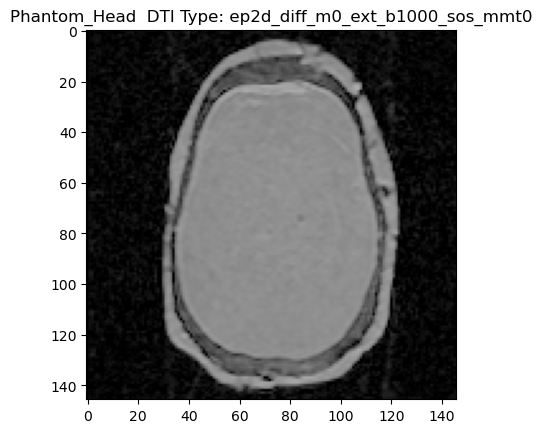

Path to header:       /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt0_Ncalib2/02_Registered_Global/Registered.header
Path to NifTi images: /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt0_Ncalib2/02_Registered_Global/Registered.nii
Shape of matrix:      
(146, 146, 1, 40)
Path to b-values:     /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt0_Ncalib2/02_Registered_Global/Registered.bvals
Path to b-vectors:    /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt0_Ncalib2/02_Registered_Global/Registered.bvecs
Number of b-values:   
40
Number of b-vectors:  
(40, 3)
Matrix 1 of 1
Number of iterations to be performed: 4000
0.25
0.5
0.75
1.0
1.25
1.5
1.7500000000000002
2.0
2.25
2.5
2.75
3.0
3.25
3.5000000000000004
3.75
4.0
4.25
4.5
4.75
5.0
5.25
5.5
5.75
6.0
6.25
6.5
6.75
7.000000000000001
7.249999999999999
7.5
7.75
8.0
8.25
8.5
8.75
9.0
9.25
9.5
9.75
10.0
10.25
10.5
10.75
11.0
11.25
11.5
11.75
12.0
12.25
12.5
12.75
13.0
13.25
13.5
13.750000000000002
14.000000000000002
14.24999999999

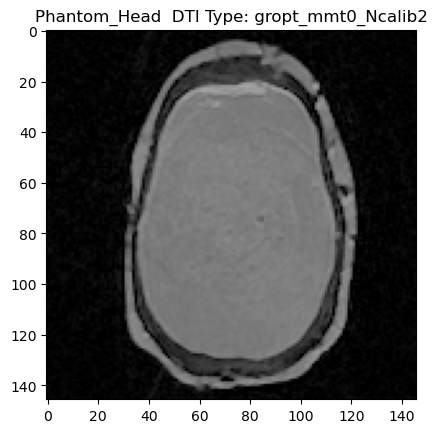

Path to header:       /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt1_Ncalib2/02_Registered_Global/Registered.header
Path to NifTi images: /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt1_Ncalib2/02_Registered_Global/Registered.nii
Shape of matrix:      
(146, 146, 1, 40)
Path to b-values:     /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt1_Ncalib2/02_Registered_Global/Registered.bvals
Path to b-vectors:    /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/gropt_mmt1_Ncalib2/02_Registered_Global/Registered.bvecs
Number of b-values:   
40
Number of b-vectors:  
(40, 3)
Matrix 1 of 1
Number of iterations to be performed: 4000
0.25
0.5
0.75
1.0
1.25
1.5
1.7500000000000002
2.0
2.25
2.5
2.75
3.0
3.25
3.5000000000000004
3.75
4.0
4.25
4.5
4.75
5.0
5.25
5.5
5.75
6.0
6.25
6.5
6.75
7.000000000000001
7.249999999999999
7.5
7.75
8.0
8.25
8.5
8.75
9.0
9.25
9.5
9.75
10.0
10.25
10.5
10.75
11.0
11.25
11.5
11.75
12.0
12.25
12.5
12.75
13.0
13.25
13.5
13.750000000000002
14.000000000000002
14.24999999999

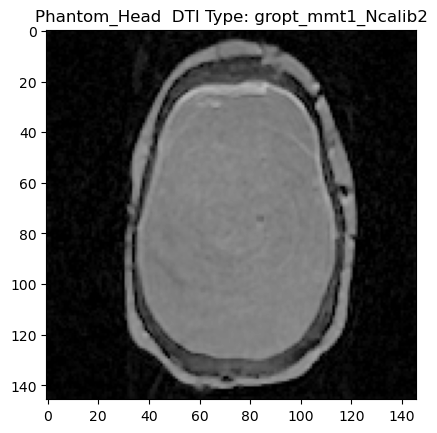

Path to header:       /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt0_Ncalib2/02_Registered_Global/Registered.header
Path to NifTi images: /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt0_Ncalib2/02_Registered_Global/Registered.nii
Shape of matrix:      
(146, 146, 1, 40)
Path to b-values:     /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt0_Ncalib2/02_Registered_Global/Registered.bvals
Path to b-vectors:    /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt0_Ncalib2/02_Registered_Global/Registered.bvecs
Number of b-values:   
40
Number of b-vectors:  
(40, 3)
Matrix 1 of 1
Number of iterations to be performed: 4000
0.25
0.5
0.75
1.0
1.25
1.5
1.7500000000000002
2.0
2.25
2.5
2.75
3.0
3.25
3.5000000000000004
3.75
4.0
4.25
4.5
4.75
5.0
5.25
5.5
5.75
6.0
6.25
6.5
6.75
7.000000000000001
7.249999999999999
7.5
7.75
8.0
8.25
8.5
8.75
9.0
9.25
9.5
9.75
10.0
10.25
10.5
10.75
11.0
11.25
11.5
11.75
12.0
12.25
12.5
12.75
13.0
13.25
13.5
13.750000000000002
14.000000000000002
14.249999999999998

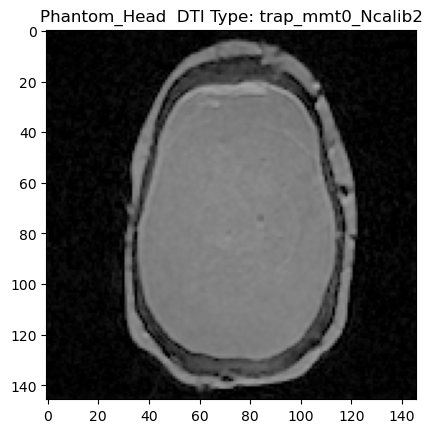

Path to header:       /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt1_Ncalib2/02_Registered_Global/Registered.header
Path to NifTi images: /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt1_Ncalib2/02_Registered_Global/Registered.nii
Shape of matrix:      
(146, 146, 1, 40)
Path to b-values:     /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt1_Ncalib2/02_Registered_Global/Registered.bvals
Path to b-vectors:    /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt1_Ncalib2/02_Registered_Global/Registered.bvecs
Number of b-values:   
40
Number of b-vectors:  
(40, 3)
Matrix 1 of 1
Number of iterations to be performed: 4000
0.25
0.5
0.75
1.0
1.25
1.5
1.7500000000000002
2.0
2.25
2.5
2.75
3.0
3.25
3.5000000000000004
3.75
4.0
4.25
4.5
4.75
5.0
5.25
5.5
5.75
6.0
6.25
6.5
6.75
7.000000000000001
7.249999999999999
7.5
7.75
8.0
8.25
8.5
8.75
9.0
9.25
9.5
9.75
10.0
10.25
10.5
10.75
11.0
11.25
11.5
11.75
12.0
12.25
12.5
12.75
13.0
13.25
13.5
13.750000000000002
14.000000000000002
14.249999999999998

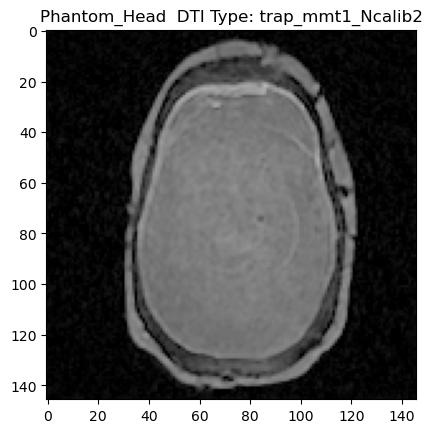

In [51]:
for ii in range(len(Subject_folders)):
    
    for DTI_type in DTI_type_list:
        #Exam_Index = Volunteers_List.index(Subject_folders[ii])

        headers   = []
        matricies = []
        bvalues   = []
        bvectors  = []
        labels    = []
        
        ### TOPUP Data
        inpath_2 = glob.glob(os.path.join(main_image_path, Subject_folders[ii], DTI_type, sub_DTI_Folder, '*ed.header'))[0]
        print('Path to header:       ' + inpath_2)
        Header = Header_Reader(inpath_2)

        inpath_3 = glob.glob(os.path.join(main_image_path, Subject_folders[ii], DTI_type, sub_DTI_Folder, '*.nii'))[0]
        print('Path to NifTi images: ' + inpath_3)
        NifTi, affine_matrix, NifTi_VoxRes = load_nifti(inpath_3, return_voxsize = True)
        #if Flip_List[Exam_Index] == 'YES':
        ##    NifTi = np.flip(NifTi[:, :, :, :], axis = 2)
        #Basal_Slice           = NifTi[:, :, Basal_Slice_List[Exam_Index], :]
        #Basal_Slice           = Basal_Slice[:, :, np.newaxis]
        #Mid_Ventricular_Slice = NifTi[:, :, Mid_Ventricualr_Slice_List[Exam_Index], :]
        #Mid_Ventricular_Slice = Mid_Ventricular_Slice[:, :, np.newaxis, :]
        #Apical_Slice          = NifTi[:, :, Apical_Slice_List[Exam_Index], :]
        #Apical_Slice          = Apical_Slice[:, :, np.newaxis, :]
        #NifTi                 = np.concatenate([Basal_Slice, Mid_Ventricular_Slice, Apical_Slice], axis = 2)
        print('Shape of matrix:      ')
        print(NifTi.shape)

        Header['X Resolution'] = NifTi_VoxRes[0]
        Header['Y Resolution'] = NifTi_VoxRes[1]
        Header['Z Resolution'] = NifTi_VoxRes[2]

        inpath_4 = glob.glob(os.path.join(main_image_path, Subject_folders[ii], DTI_type, sub_DTI_Folder, '*.bvals'))[0]
        print('Path to b-values:     ' + inpath_4)
        inpath_5 = glob.glob(os.path.join(main_image_path, Subject_folders[ii], DTI_type, sub_DTI_Folder, '*.bvecs'))[0]
        print('Path to b-vectors:    ' + inpath_5)
        bvals, bvecs = read_bvals_bvecs(inpath_4, inpath_5)
        print('Number of b-values:   ')
        print(len(bvals))
        print('Number of b-vectors:  ')
        print(bvecs.shape)
        headers.append(Header)
        matricies.append(NifTi)
        bvalues.append(bvals)
        bvectors.append(bvecs)
    #     labels.append(DTI_folders[ii])

        del inpath_2, inpath_3, inpath_4, inpath_5, Header, NifTi, affine_matrix, NifTi_VoxRes, bvals, bvecs
        
        bootstrap_matricies = []
        bootstrap_bvalues   = []
        bootstrap_bvectors  = []
    #     iterations          = 400
        for idx in range(len(matricies)):
            print("Matrix %i of %i" %(idx + 1, len(matricies)))
            start = time.time()
            [temp_matrix, temp_bvals, temp_bvecs] = stacked2sorted(matricies[idx], bvalues[idx], bvectors[idx])
            desired_averages                      = temp_matrix.shape[4]
    #         print(desired_averages)
            [_, averaged_bootstrap_matrix] = diffusion_bootstrap(temp_matrix, temp_bvals, temp_bvecs, desired_averages, iterations)
            bootstrap_matricies.append(averaged_bootstrap_matrix)
            bootstrap_bvalues.append(temp_bvals)
            bootstrap_bvectors.append(temp_bvecs)
            del temp_matrix, temp_bvals, temp_bvecs, desired_averages, averaged_bootstrap_matrix
            end = time.time()
            print(end - start)
            
        del matricies, bvalues, bvectors
        
    #     print(labels[ii])
    #     print(bootstrap_matricies[ii].shape)
    #     print(len(bootstrap_bvalues[ii]))
    #     print(bootstrap_bvectors[ii].shape)
        
        bootstrap_registered_matricies   = []

        registration_algorithm    = 'Rigid'         # Type of registration to perform
        temporary_denoising       = 'OFF'
        operation_type            = 'Complex'      #
        #denoising_algorithm       = 'LocalPCA'       # Type of denoising to perform

        num_cores           = int(10)

        start_final = time.time()
        for idx in range(len(bootstrap_matricies)):
            start = time.time()
            print("Matrix %i of %i" %(idx + 1, len(bootstrap_matricies)))
            temp_matrix = bootstrap_matricies[idx]
            temp_bvals  = bootstrap_bvalues[idx]
            temp_bvecs  = bootstrap_bvectors[idx]

            rows = temp_matrix.shape[0]
            cols = temp_matrix.shape[1]
            slcs = temp_matrix.shape[2]
            difs = temp_matrix.shape[3]
            avgs = temp_matrix.shape[4]

            registered_matrix   = np.zeros([rows, cols, slcs, difs, avgs], dtype = temp_matrix.dtype)
        


            inputs = range(avgs)
            results = Parallel(n_jobs = num_cores)(delayed(processInput)(temp_matrix, temp_bvals, temp_bvecs, iters) for iters in inputs)
            for avg in range(len(results)):
                registered_matrix  [:, :, :, :, avg] = results[avg][0][:, :, :, :, 0]
            
            bootstrap_registered_matricies.append(registered_matrix)

            del temp_matrix, temp_bvals, temp_bvecs, rows, cols, slcs, difs, avgs, inputs, results, registered_matrix
            end = time.time()
            print(end - start)
        end_final = time.time()
        print(end_final - start_final)
        
    #     iterations          = 1000
        # DTI_Folder_List     = [DTI_BD_folder, DTI_BU_folder, DTI_DB_folder, DTI_TU_folder]
        DTI_sub_Folder_List = ['Averaged_' + str(iterations) +  '_Bootstraps', 'Registered_' + str(iterations) +  '_Bootstraps']
        matrix_list         = [bootstrap_matricies, bootstrap_registered_matricies]
        #     inpath_4 = glob.glob(os.path.join(main_image_path, subject_folder, DTI_folder, DTI_folders[ii], DTI_type, sub_DTI_Folder, '*.bvals'))[0]
        # subject_folder, DTI_folder, DTI_folders[ii], DTI_type, sub_DTI_Folder
        for idx_1 in range(len(bootstrap_matricies)):
            print(Subject_folders[ii])
            for idx_2 in range(len(DTI_sub_Folder_List)):
                print(DTI_sub_Folder_List[idx_2])
                outpath     = os.path.join(main_outpath, Subject_folders[ii], DTI_type, str(idx_2).zfill(2) + '_' + DTI_sub_Folder_List[idx_2])
                temp_matrix = matrix_list[idx_2][idx_1]
                temp_bvals  = bootstrap_bvalues[idx]
                temp_bvecs  =  bootstrap_bvectors[idx]
                if idx_2 == len(DTI_sub_Folder_List) - 1:
                    Header = headers[idx_1]
                    Header['X Resolution'] = float(Header['X Resolution'] / 2)
                    Header['Y Resolution'] = float(Header['Y Resolution'] / 2)
                    print(Header)
                    Save_Diffusion_Image_Data(outpath, DTI_sub_Folder_List[idx_2], Header, temp_matrix, temp_bvals, temp_bvecs)
                    Header['X Resolution'] = float(Header['X Resolution'] * 2)
                    Header['Y Resolution'] = float(Header['Y Resolution'] * 2)            
                    #del Header
                else:
                    Header = headers[idx_1]
                    print(Header)
                    Save_Diffusion_Image_Data(outpath, DTI_sub_Folder_List[idx_2], Header, temp_matrix, temp_bvals, temp_bvecs)
                    #del Header

        Bootstrap_DTI_Metrics  = []
        Bootstrap_Eigenvectors = []

        num_cores = int(10)

        for idx in range(len(bootstrap_registered_matricies)):
            start = time.time()
            print("Matrix %i of %i" %(idx + 1, len(bootstrap_registered_matricies)))
            temp_matrix = bootstrap_registered_matricies[idx]
            temp_bvals  = bootstrap_bvalues[idx]
            temp_bvecs  = bootstrap_bvectors[idx]

            inputs = range(temp_matrix.shape[4])
            #print("inputs type:", type(inputs))
            #print("first 5 inputs:", list(inputs)[:5])
            results = Parallel(n_jobs=num_cores)(delayed(bootstrapped_DTI_recon_MP)(temp_matrix, temp_bvals, temp_bvecs, iters) for iters in inputs)

            rows = temp_matrix.shape[0]
            cols = temp_matrix.shape[1]
            slcs = temp_matrix.shape[2]
            avgs = temp_matrix.shape[4]

            MD_matrix   = np.zeros([rows, cols, slcs, avgs])

            for avg in range(len(results)):
                MD_matrix[:, :, :, avg]    = results[avg][0]['ADC']

            Bootstrapped_DTI_Metrics = dict()
            Bootstrapped_DTI_Metrics['ADC'] =  MD_matrix

            Bootstrap_DTI_Metrics.append(Bootstrapped_DTI_Metrics)
            del temp_matrix, temp_bvals, temp_bvecs, inputs, results, rows, cols, slcs, avgs
            del MD_matrix
            del Bootstrapped_DTI_Metrics
            end = time.time()
            print(end - start)    
            

    #     iterations          = 1000
        # DTI_Folder_List     = [DTI_BD_folder, DTI_BU_folder, DTI_DB_folder, DTI_TU_folder]
        DTI_sub_Folder_List = ['Standard_DWI_Metrics_' + str(iterations) +  '_Bootstraps']
        matrix_list         = [Bootstrap_DTI_Metrics]
        for idx_1 in range(len(bootstrap_registered_matricies)):
            print(Subject_folders[ii])
            for idx_2 in range(len(DTI_sub_Folder_List)):
                print(DTI_sub_Folder_List[idx_2])
                outpath     = os.path.join(main_outpath, Subject_folders[ii], DTI_type, str(idx_2 + 4).zfill(2) + '_' + DTI_sub_Folder_List[idx_2])
                if os.path.isdir(outpath) == False:
                    os.makedirs(outpath)
                outpath_mat = os.path.join(outpath, DTI_sub_Folder_List[idx_2] + '.mat')
                savemat(outpath_mat, matrix_list[idx_2][idx_1])

        # Plot an example ADC 
        plt.imshow(Bootstrap_DTI_Metrics[0]['ADC'][:, :, 0, 0],vmin = 0, vmax = 3,cmap = 'gray')
        plt.title(Subject_folders[ii] + '  DTI Type: ' + DTI_type)
        plt.show()
        del matrix_list, Bootstrap_DTI_Metrics, Bootstrap_Eigenvectors

In [52]:
inpath_2 = glob.glob(os.path.join(main_image_path, Subject_folders[ii], DTI_type, sub_DTI_Folder, '*ed.header'))[0]
print('Path to header:       ' + inpath_2)
Header = Header_Reader(inpath_2)

inpath_3 = glob.glob(os.path.join(main_image_path, Subject_folders[ii], DTI_type, sub_DTI_Folder, '*.nii'))[0]
print('Path to NifTi images: ' + inpath_3)
NifTi, affine_matrix, NifTi_VoxRes = load_nifti(inpath_3, return_voxsize = True)
#if Flip_List[Exam_Index] == 'YES':
##    NifTi = np.flip(NifTi[:, :, :, :], axis = 2)
#Basal_Slice           = NifTi[:, :, Basal_Slice_List[Exam_Index], :]
#Basal_Slic

Path to header:       /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt1_Ncalib2/02_Registered_Global/Registered.header
Path to NifTi images: /Volumes/T7/Stim-CODE/NifTi/Phantom_Head/trap_mmt1_Ncalib2/02_Registered_Global/Registered.nii
